In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, Graphs

train_info = GraphsTraining()

In [2]:
results_reg_norm = load_all_pickles("results/pyomo_vdp_reg_norm", recursive=False)
results_reg_norm_df = Results.flatten_convergence_data(results_reg_norm, key_list=["system", "reg", "tol"], model_type="pyomo")

results_reg_norm_1 = load_all_pickles("results/pyomo_vdp_reg_norm_1", recursive=False)
results_reg_norm_1_df = Results.flatten_convergence_data(results_reg_norm_1, key_list=["system", "reg", "tol"], model_type="pyomo")

results_no_reg_norm = load_all_pickles("results/pyomo_vdp_no_reg_norm_0_001", recursive=False)
results_no_reg_norm_df = Results.flatten_convergence_data(results_no_reg_norm, key_list=["system", "reg", "tol"], model_type="pyomo")

Loaded results/pyomo_vdp_reg_norm/1046558864_2026-02-14_15-33.pkl
Loaded results/pyomo_vdp_reg_norm/160528624_2026-02-14_18-11.pkl
Loaded results/pyomo_vdp_reg_norm/1810406202_2026-02-14_15-52.pkl
Loaded results/pyomo_vdp_reg_norm/1841249980_2026-02-14_18-07.pkl
Loaded results/pyomo_vdp_reg_norm/1899346228_2026-02-14_16-02.pkl
Loaded results/pyomo_vdp_reg_norm/199628660_2026-02-14_15-23.pkl
Loaded results/pyomo_vdp_reg_norm/2030831349_2026-02-14_15-57.pkl
Loaded results/pyomo_vdp_reg_norm/2035062890_2026-02-14_16-09.pkl
Loaded results/pyomo_vdp_reg_norm/2140096489_2026-02-14_18-02.pkl
Loaded results/pyomo_vdp_reg_norm/2183347929_2026-02-14_16-05.pkl
Loaded results/pyomo_vdp_reg_norm/2209253869_2026-02-14_18-10.pkl
Loaded results/pyomo_vdp_reg_norm/2271656020_2026-02-14_18-07.pkl
Loaded results/pyomo_vdp_reg_norm/2291888075_2026-02-14_15-30.pkl
Loaded results/pyomo_vdp_reg_norm/2427327915_2026-02-14_16-17.pkl
Loaded results/pyomo_vdp_reg_norm/2674500715_2026-02-14_15-38.pkl
Loaded resul

In [3]:
# results_reg_norm_df = results_reg_norm_df[results_reg_norm_df["time_elapsed"] < 100]
# results_reg_norm_1_df = results_reg_norm_1_df[results_reg_norm_1_df["time_elapsed"] < 100]
# results_no_reg_norm_df = results_no_reg_norm_df[results_no_reg_norm_df["time_elapsed"] < 100]

In [4]:
results_reg_norm_1_df.groupby("system").size()

system
(2, 4, 2)      15
(2, 8, 2)      15
(2, 16, 2)     15
(2, 32, 2)     15
(2, 64, 2)     15
(2, 96, 2)     15
(2, 128, 2)    15
dtype: int64

In [5]:
results_no_reg_norm_df.groupby("system")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
system,,,
"(2, 4, 2)",12.483190,0.042709,1.155610
"(2, 8, 2)",19.106271,2.047605,4.257537
"(2, 16, 2)",7.120026,1.074157,2.254503
"(2, 32, 2)",12.850810,0.169599,2.513555
"(2, 64, 2)",15.734124,0.026509,1.364321
"(2, 96, 2)",24.983407,0.011640,1.132867
"(2, 128, 2)",20.515666,0.016957,1.404742


In [6]:
results_reg_norm_df.groupby("system")[["time_elapsed", "mse_train_coll", "mse_test_coll"]].mean()

,time_elapsed,mse_train_coll,mse_test_coll
system,,,
"(2, 4, 2)",11.568642,0.311185,2.506277
"(2, 8, 2)",13.551480,0.820908,2.264551
"(2, 16, 2)",9.048527,0.451780,2.161653
"(2, 32, 2)",13.759661,0.298443,2.739100
"(2, 64, 2)",77.209873,0.616661,2.139427
"(2, 96, 2)",26.614686,0.874314,1.556147
"(2, 128, 2)",71.621510,0.326950,1.935407


In [7]:
results_reg_norm_df.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed
0,"(2, 4, 2)",0.1,0.000001,20.370525,"[[1.5310175248593025e-15, 0.001934983651075251...","[[0.0, 1.0], [0.0019264311, 1.0014565], [0.010...","[[1.9083185, -0.77511317], [1.9052931, -0.7821...",22.679255,270.993896,2.88443,14.960707,optimal,1046558864


In [8]:
results_no_reg_norm_df.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed
0,"(2, 4, 2)",0.001,0.000001,23.633463,"[[1.2673563982103434e-16, 0.000275777790529724...","[[0.0, 1.0], [0.00027552684, 1.0016934], [0.00...","[[1.9083185, -0.77511317], [1.9063884, -0.7763...",0.093233,1.458701,0.046779,1.303986,optimal,1239495072


In [9]:
results_no_reg_norm_df["system"] = results_no_reg_norm_df["system"].apply(lambda x: x[1])
results_reg_norm_df["system"] = results_reg_norm_df["system"].apply(lambda x: x[1])

In [13]:
reg_norm_df = Results.prep_for_boxplots(results_reg_norm_df,  'system',  'mse_train_coll')
no_reg_norm_df = Results.prep_for_boxplots(results_no_reg_norm_df,  'system',  'mse_train_coll')

reg_norm_df = Results.prep_for_boxplots(results_reg_norm_df,  'system',  'time_elapsed')
no_reg_norm_df = Results.prep_for_boxplots(results_no_reg_norm_df,  'system',  'time_elapsed')

reg_norm_df = Results.prep_for_boxplots(results_reg_norm_df,  'system',  'mse_test_coll')
no_reg_norm_df = Results.prep_for_boxplots(results_no_reg_norm_df,  'system',  'mse_test_coll')

In [14]:
# results_no_reg_norm_df

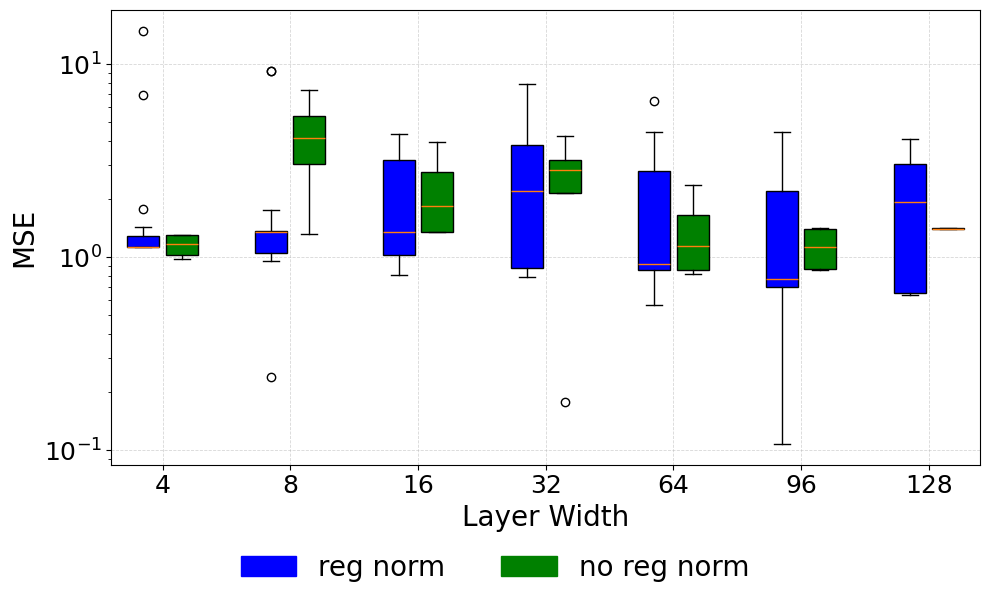

<Axes: xlabel='Layer Width', ylabel='MSE'>

In [16]:
Graphs.plot_boxplots_custom(reg_norm_df['mse_test_coll'], no_reg_norm_df['mse_test_coll'], reg_norm_df.x_labels, 
            '',     
              'MSE', color_labels=["reg norm", "no reg norm"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )